# 00 — Optionally define `mask_pixel` with Paint

This is the PNG/Paint alternative to `00a_define_mask_pixel_napari.ipynb`. It loads raw detector images and creates one raw-coordinate mask per image **before FTH**. Run it before optional stitching as well, because stitching uses these masks.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

BASEFOLDER = Path.cwd().resolve()
ROOT = BASEFOLDER
sys.path.insert(0, str(ROOT))
from library.data_loading import SextantsNexusLoader
from library.mask_store import MaskStore
from library.painted_masks import mask_png_paths, save_mask_reference_png

import os, sys
from os.path import join
sys.path.append(join(BASEFOLDER, "library"))
print("Base folder:", BASEFOLDER)
import helper_functions as helper
print("Project root:", ROOT)

Base folder: /home/experiences/sextants/com-sextants/SEXT_NEW
Project root: /home/experiences/sextants/com-sextants/SEXT_NEW


## Select raw images and export Paint references

In [2]:
# Include every raw image used directly by FTH or by stitching.
IMAGE_IDS = [439,440]
RAW_FOLDER = Path("/home/experiences/sextants/com-sextants/ruche/sextants-soleil/com-sextants/COMET_20260902_Cocoons_Laser/")
RAW_FOLDER = Path("../COMET_20260902_Cocoons_Laser_raw/")

RAW_FOLDER = "/nfs/ruche/sextants-soleil/com-sextants/COMET_20260902_Cocoons_Laser/"

RAW_DATA_FOLDER = RAW_FOLDER
loader = SextantsNexusLoader(RAW_DATA_FOLDER)
mask_store = MaskStore(ROOT / "processed" / "mask_pixels")

frames = {image_id: loader.load(image_id) for image_id in IMAGE_IDS}

In [3]:
for image_id, frame in frames.items():
    reference_png, painted_png = mask_png_paths(ROOT, "mask_pixel", image_id)
    save_mask_reference_png(frame.image, reference_png, log_scale=True)
    print(f"Image {image_id}: {frame.image.shape}, exposure={frame.exposure:g}")
    print("  Open in Paint:", reference_png)
    print("  Paint mask pixels bright red and save as:", painted_png)

Image 439: (2048, 2048), exposure=25
  Open in Paint: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/mask_pixels/mask_pixel_439_reference.png
  Paint mask pixels bright red and save as: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/mask_pixels/mask_pixel_439.png
Image 440: (2048, 2048), exposure=25
  Open in Paint: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/mask_pixels/mask_pixel_440_reference.png
  Paint mask pixels bright red and save as: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/mask_pixels/mask_pixel_440.png


FileNotFoundError: [Errno 2] No such file or directory: '/home/experiences/sextants/com-sextants/SEXT_NEW/processed/masks/mask_pixel_439.npy'

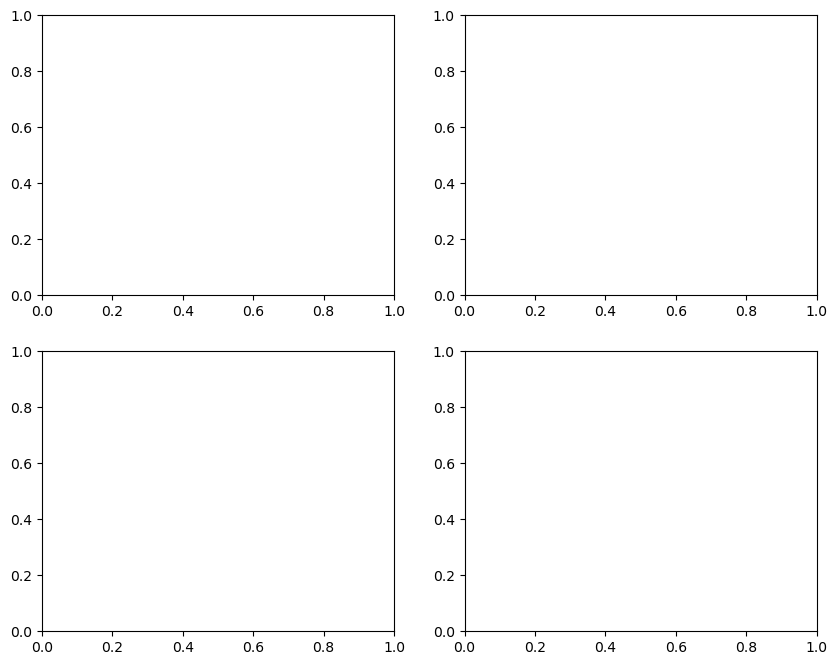

In [4]:
fig, axes = plt.subplots(len(IMAGE_IDS), 2, figsize=(10, 4 * len(IMAGE_IDS)), squeeze=False)
for row, image_id in enumerate(IMAGE_IDS):
    frame = frames[image_id]
    mask_pixel = mask_store.load(image_id, frame.image.shape)
    # Re-save in canonical pure-red form after validation.
    saved_path = mask_store.save(image_id, mask_pixel)
    axes[row, 0].imshow(frame.image, cmap="gray")
    axes[row, 0].imshow(mask_pixel, alpha=0.35, cmap="Reds", vmin=0, vmax=1)
    axes[row, 0].set_title(f"raw image {image_id} + mask")
    axes[row, 1].imshow(mask_pixel, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"mask_pixel_{image_id}.png")
    for axis in axes[row]:
        axis.set_axis_off()
    print(f"Image {image_id}: saved {int(mask_pixel.sum())} masked pixels to {saved_path}")
fig.tight_layout()
plt.show()

In [6]:


USER = "rb"
CLEANED_FOLDER = BASEFOLDER / "processed" / "cleaned_acquisitions"
IMAGE_IDS = {
    "+": [454, 456, 458, 460, 462],
    "-": [455, 457, 459, 461, 463],
}
MASK_ID = 95
CENTER_START = [1002, 1037]
ROI = [597, 785, 526, 719]
BUTTERWORTH_RADIUS = 35
BUTTERWORTH_ORDER = 4
PIXEL_MASK_SMOOTHING = 3

In [7]:
loaded_images = {"+": [], "-": []}
loaded_files = {"+": [], "-": []}
thresholds = {"+": [], "-": []}
dark_ids = None
energy = ccd_dist = px_size = None

for label, image_ids in IMAGE_IDS.items():
    for image_id in image_ids:
        input_file = CLEANED_FOLDER / f"cleaned_ImId_{image_id:04d}_{USER}.npz"
        with np.load(input_file, allow_pickle=False) as saved:
            saved_id = int(saved["image_id"])
            if saved_id != image_id:
                raise ValueError(f"Acquisition metadata does not match {input_file}")
            loaded_images[label].append(np.asarray(saved["image"], dtype=float))
            thresholds[label].append(float(saved["threshold"]))
            current_dark_ids = saved["dark_ids"].astype(int).tolist()
            current_setup = (
                float(saved["energy_eV"]),
                float(saved["ccd_dist_m"]),
                float(saved["px_size_m"]),
            )
        if dark_ids is None:
            dark_ids = current_dark_ids
            energy, ccd_dist, px_size = current_setup
        elif current_dark_ids != dark_ids or current_setup != (energy, ccd_dist, px_size):
            raise ValueError("Selected acquisitions do not share dark IDs and geometry")
        loaded_files[label].append(input_file)
        print(f"Loaded {label} ID {image_id}: {input_file}")

# This is the first point where separate acquisition IDs are merged.
positive = np.mean(np.stack(loaded_images["+"]), axis=0, dtype=np.float64)
negative = np.mean(np.stack(loaded_images["-"]), axis=0, dtype=np.float64)
positive_ids = [int(image_id) for image_id in IMAGE_IDS["+"]]
negative_ids = [int(image_id) for image_id in IMAGE_IDS["-"]]
if positive.shape != negative.shape or positive.ndim != 2:
    raise ValueError(f"Expected matching 2-D averages, got {positive.shape} and {negative.shape}")

im_id, topo_id = positive_ids[0], negative_ids[0]
folder_general = Path(helper.create_folder(BASEFOLDER / "processed"))
folder_logs = Path(helper.create_folder(folder_general / "Logs"))
DATA_H5 = folder_logs / f"data_recon_ImId_{im_id:04d}_{USER}.hdf5"
experimental_setup = {
    "ccd_dist": ccd_dist, "px_size": px_size, "binning": 1,
    "oversaturation": 60e3, "energy": energy,
    "lambda": helper.photon_energy_wavelength(energy, input_unit="eV"),
}
data = {
    "workflow": "FTH_from_cleaned_3d_averages",
    "user": USER, "data_file": str(DATA_H5),
    "experimental_setup": experimental_setup,
    "positive_label": "+", "reference_label": "-",
    "hologram_labels": ["+", "-"],
    "preprocessed_files": {
        label: [str(path) for path in paths] for label, paths in loaded_files.items()
    },
    "intensity_thresholds": thresholds,
    "holo": {
        "+": {"id": positive_ids, "dark_id": dark_ids, "image": positive},
        "-": {"id": negative_ids, "dark_id": dark_ids, "image": negative},
    },
}
print("Merged shapes:", positive.shape, negative.shape)
print("Output HDF5:", DATA_H5)

Loaded + ID 454: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0454_rb.npz
Loaded + ID 456: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0456_rb.npz
Loaded + ID 458: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0458_rb.npz
Loaded + ID 460: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0460_rb.npz
Loaded + ID 462: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0462_rb.npz
Loaded - ID 455: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0455_rb.npz
Loaded - ID 457: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0457_rb.npz
Loaded - ID 459: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/cleaned_acquisitions/cleaned_ImId_0459_rb.npz
Loaded - ID 461: /home/e

In [8]:


frame=data["holo"]["+"]["image"]+data["holo"]["-"]["image"]

reference_png, painted_png = mask_png_paths(ROOT, "mask_pixel", IMAGE_IDS["+"])
save_mask_reference_png(np.log(frame-np.amin(frame)+0.01), reference_png, log_scale=True)
print("  Open in Paint:", reference_png)
print("  Paint mask pixels bright red and save as:", painted_png)

  Open in Paint: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/mask_pixels/mask_pixel_[454, 456, 458, 460, 462]_reference.png
  Paint mask pixels bright red and save as: /home/experiences/sextants/com-sextants/SEXT_NEW/processed/mask_pixels/mask_pixel_[454, 456, 458, 460, 462].png


AttributeError: 'dict' object has no attribute 'image'

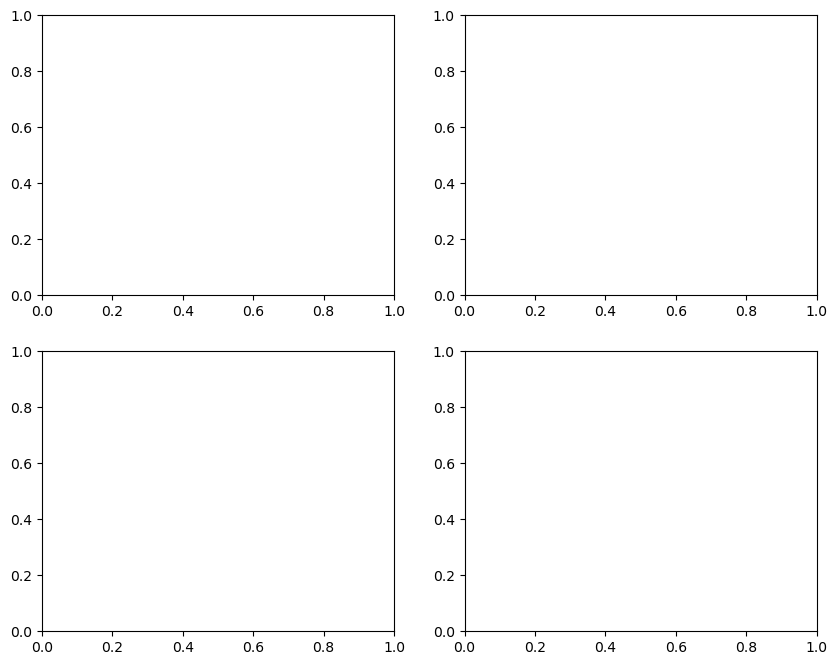

In [9]:
fig, axes = plt.subplots(len(IMAGE_IDS), 2, figsize=(10, 4 * len(IMAGE_IDS)), squeeze=False)
for row, image_id in enumerate(IMAGE_IDS):
    frame = data
    mask_pixel = mask_store.load(image_id, frame.image.shape)
    # Re-save in canonical pure-red form after validation.
    saved_path = mask_store.save(image_id, mask_pixel)
    axes[row, 0].imshow(frame.image, cmap="gray")
    axes[row, 0].imshow(mask_pixel, alpha=0.35, cmap="Reds", vmin=0, vmax=1)
    axes[row, 0].set_title(f"raw image {image_id} + mask")
    axes[row, 1].imshow(mask_pixel, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"mask_pixel_{image_id}.png")
    for axis in axes[row]:
        axis.set_axis_off()
    print(f"Image {image_id}: saved {int(mask_pixel.sum())} masked pixels to {saved_path}")
fig.tight_layout()
plt.show()

## Paint and save

Open each `_reference.png`, paint unusable pixels pure red (RGB 255, 0, 0), and save it under the printed filename without `_reference`. Keep the canvas dimensions unchanged. Then run the cell below.

In [ ]:
# Acquisition ID summary
print("im_ids:", globals().get("IMAGE_IDS", globals().get("SCAN_IDS", None)))
print("dark_ids:", globals().get("DARK_IDS", None))